# Solución del laboratorio 8: UPS ORION: ordenar entregas con compromisos
**Profesor de laboratorio: Manuel López.** Material docente.
Los resultados guardados corresponden a la ejecución del mismo código en Python. Abra el notebook desde esta carpeta para conservar las rutas relativas.
El desarrollo matemático, la interpretación y la pauta de corrección están en el archivo .tex asociado.


rutas_24
   secuencia  tiempo  tardanza  cumplimiento
(1, 2, 3, 4)      29      10.0          0.50
(1, 2, 4, 3)      29       7.0          0.75
(1, 3, 2, 4)      26       3.0          0.75
(1, 3, 4, 2)      26       0.0          1.00
(1, 4, 2, 3)      28       6.0          0.75
(1, 4, 3, 2)      28       0.0          1.00
(2, 1, 3, 4)      32      25.0          0.25
(2, 1, 4, 3)      34      23.0          0.25
(2, 3, 1, 4)      31      28.0          0.25
(2, 3, 4, 1)      28      32.0          0.25
(2, 4, 1, 3)      31      20.0          0.50
(2, 4, 3, 1)      26      26.0          0.50
(3, 1, 2, 4)      32      17.0          0.50
(3, 1, 4, 2)      31      11.0          0.25
(3, 2, 1, 4)      34      29.0          0.50
(3, 2, 4, 1)      28      27.0          0.50
(3, 4, 1, 2)      34      18.0          0.50
(3, 4, 2, 1)      29      22.0          0.50
(4, 1, 2, 3)      34      16.0          0.50
(4, 1, 3, 2)      31       8.0          0.25
(4, 2, 1, 3)      32      22.0          0.50


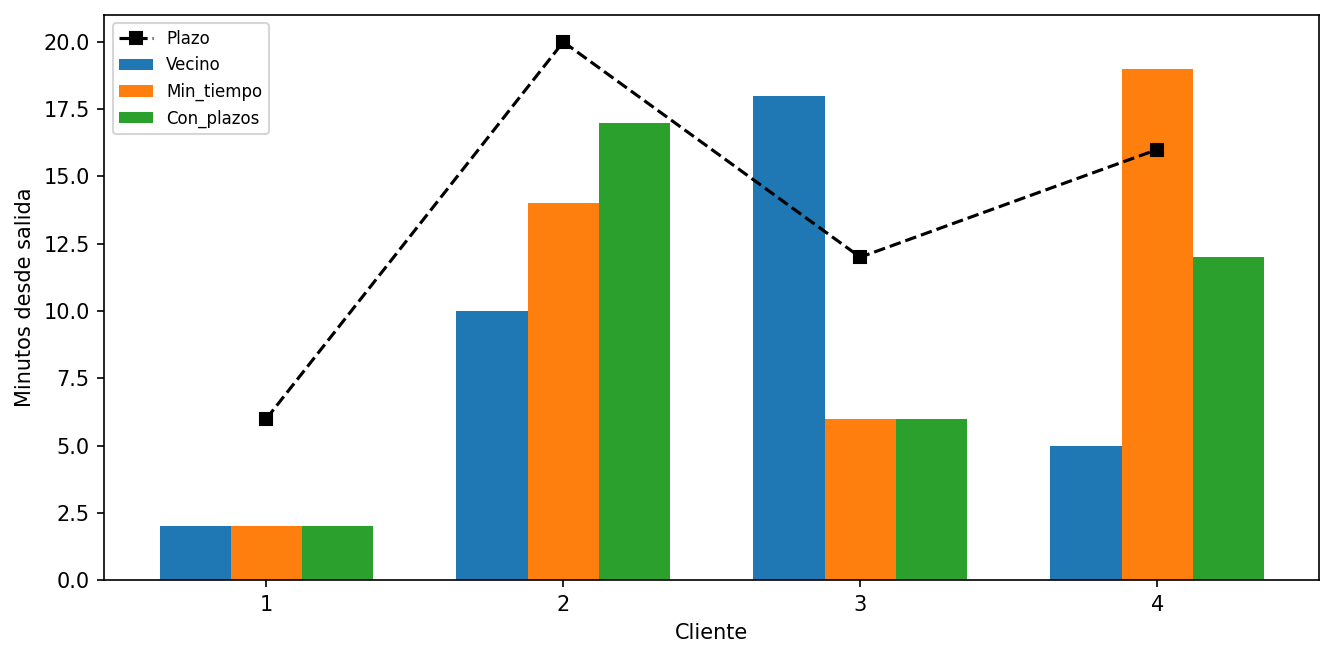

In [1]:
"""Solución docente de Gestión de Operaciones. Profesor: Manuel López."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
datos = base / "datos"
salida = base / "resultados"
salida.mkdir(exist_ok=True)
parametros = json.loads((datos / "parametros.json").read_text(encoding="utf-8"))

def tabla(df, nombre):
    df.to_csv(salida / (nombre + ".csv"), index=False)
    visible = df if len(df) <= 28 else df.head(12)
    print("\n" + nombre + "\n" + visible.to_string(index=False))
    if len(df) > 28:
        print(f"Vista inicial: {len(df)} filas completas en {nombre}.csv")

def figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(salida / (nombre + ".png"), dpi=150, bbox_inches="tight")
    if "__file__" not in globals():
        plt.show()
    plt.close(fig)

def resumen(obj):
    def convertir(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, np.generic):
            return x.item()
        raise TypeError(type(x))
    (salida / "resumen.json").write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=convertir),
        encoding="utf-8")

from itertools import permutations
nodos=pd.read_csv(datos / "nodos.csv")
viajes=pd.read_csv(datos / "viajes.csv")
deposito=parametros["deposito"]; tol=parametros["tolerancia"]
clientes=sorted(nodos.loc[nodos.tipo.eq("cliente"),"nodo"].tolist())
limites=nodos.set_index("nodo").limite_llegada_min.to_dict()
tau=viajes.set_index(["origen","destino"]).tiempo_min.to_dict()
assert len(tau)==20 and all(tau[i,j]==tau[j,i] for i,j in tau)
assert nodos.servicio_min.eq(0).all()

def evaluar(seq):
    assert sorted(seq)==clientes
    t=parametros["salida_min"]; anterior=deposito; filas=[]
    for j in seq:
        t+=tau[anterior,j]
        filas.append({"cliente":j,"llegada":t,"limite":limites[j],
                      "tardanza":max(t-limites[j],0),"a_tiempo":t<=limites[j]+tol})
        anterior=j
    detalle=pd.DataFrame(filas)
    return {"secuencia":tuple(seq),"tiempo":t+tau[anterior,deposito],
            "tardanza":float(detalle.tardanza.sum()),
            "cumplimiento":float(detalle.a_tiempo.mean()),"detalle":detalle}

no_visitados=set(clientes); actual=deposito; vecino=[]
while no_visitados:
    siguiente=min(no_visitados,key=lambda j:(tau[actual,j],j))
    vecino.append(siguiente); no_visitados.remove(siguiente); actual=siguiente
rutas=[evaluar(seq) for seq in permutations(clientes)]
libre=min(rutas,key=lambda r:(r["tiempo"],r["secuencia"]))
factibles=[r for r in rutas if r["cumplimiento"]==1]
if not factibles:
    raise ValueError("No hay una ruta que cumpla todos los plazos")
con_plazos=min(factibles,key=lambda r:(r["tiempo"],r["secuencia"]))
pol={"Vecino":evaluar(vecino),"Min_tiempo":libre,"Con_plazos":con_plazos}
tabla(pd.DataFrame([{k:v for k,v in r.items() if k!="detalle"} for r in rutas]),"rutas_24")
resultados=[]; fig,ax=plt.subplots(figsize=(9,4.5))
pos=np.arange(len(clientes)); ancho=0.24
for k,(nombre,r) in enumerate(pol.items()):
    tabla(r["detalle"],"llegadas_"+nombre)
    fila={key:value for key,value in r.items() if key!="detalle"}
    fila["politica"]=nombre; resultados.append(fila)
    orden=r["detalle"].set_index("cliente").loc[clientes]
    ax.bar(pos+(k-1)*ancho,orden.llegada,width=ancho,label=nombre)
ax.plot(pos,[limites[j] for j in clientes],"ks--",label="Plazo")
ax.set_xticks(pos,[str(j) for j in clientes]); ax.set(xlabel="Cliente",ylabel="Minutos desde salida")
ax.legend(fontsize=8); figura(fig,"llegadas_y_plazos")
tabla(pd.DataFrame(resultados),"comparacion")
assert pol["Vecino"]["tiempo"]==28 and pol["Vecino"]["tardanza"]==6
assert libre["secuencia"]==(1,3,2,4) and libre["tardanza"]==3
assert con_plazos["secuencia"]==(1,3,4,2) and con_plazos["tiempo"]==26
resumen({"politicas":resultados,"numero_factibles":len(factibles),
         "minimos_sin_plazos":[r["secuencia"] for r in rutas if r["tiempo"]==libre["tiempo"]]})
